# CNN and RNN Implementation

**CNN Dataset:** MNIST handwritten digits  
**RNN Dataset:** IMDB movie reviews


In [ ]:
# Cell 1: Install and Import Libraries
%pip install tensorflow -q
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully")


TensorFlow version: 2.21.0
Libraries imported successfully


## Part A — Convolutional Neural Network (CNN)
MNIST contains grayscale handwritten digit images. CNN learns spatial patterns such as edges and shapes.

In [ ]:
# Cell 2: Load MNIST Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("MNIST dataset loaded successfully")
print("Training images:", x_train.shape)
print("Testing images :", x_test.shape)
print("Number of classes:", len(np.unique(y_train)))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST dataset loaded successfully
Training images: (60000, 28, 28)
Testing images : (10000, 28, 28)
Number of classes: 10


In [ ]:
# Cell 3: Preprocess MNIST Data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
print("Data normalized successfully")
print("Training data shape:", x_train.shape)
print("Testing data shape :", x_test.shape)


Data normalized successfully
Training data shape: (60000, 28, 28, 1)
Testing data shape : (10000, 28, 28, 1)


In [ ]:
# Cell 4: Build CNN Model
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])
cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 5: Train CNN
cnn_history = cnn_model.fit(
    x_train, y_train, epochs=5, batch_size=64,
    validation_split=0.1, verbose=1
)
print("CNN training completed successfully")


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 59s 65ms/step - accuracy: 0.9492 - loss: 0.1674 - val_accuracy: 0.9810 - val_loss: 0.0588
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 52s 61ms/step - accuracy: 0.9834 - loss: 0.0529 - val_accuracy: 0.9817 - val_loss: 0.0633
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.9893 - loss: 0.0360 - val_accuracy: 0.9903 - val_loss: 0.0340
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 53s 63ms/step - accuracy: 0.9916 - loss: 0.0263 - val_accuracy: 0.9907 - val_loss: 0.0321
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 59ms/step - accuracy: 0.9933 - loss: 0.0208 - val_accuracy: 0.9850 - val_loss: 0.0524
CNN training completed successfully


In [ ]:
# Cell 6: Evaluate CNN
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test, verbose=0)
print("CNN Test Loss:", round(cnn_loss, 4))
print("CNN Test Accuracy:", round(cnn_accuracy * 100, 2), "%")


CNN Test Loss: 0.0423
CNN Test Accuracy: 98.66 %


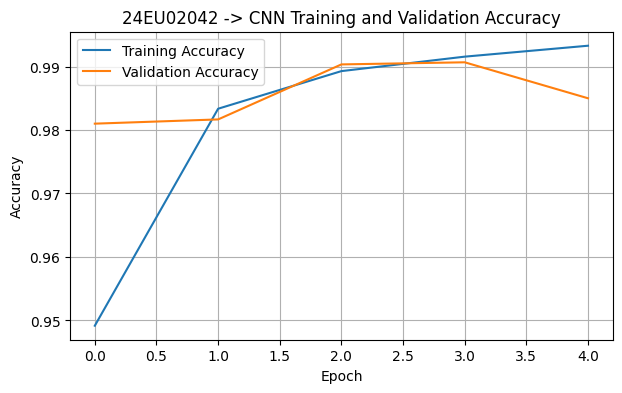

CNN performance graph generated successfully


In [ ]:
# Cell 7: CNN Training Performance
plt.figure(figsize=(7, 4))
plt.plot(cnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("24EU02042 -> CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()
print("CNN performance graph generated successfully")


## Part B — Recurrent Neural Network (RNN)
IMDB contains movie reviews labeled positive or negative. RNN processes the sequence of words and learns information from their order.

In [ ]:
# Cell 8: Load IMDB Dataset
num_words = 10000
(x_train_rnn, y_train_rnn), (x_test_rnn, y_test_rnn) = tf.keras.datasets.imdb.load_data(num_words=num_words)
print("IMDB dataset loaded successfully")
print("Training reviews:", len(x_train_rnn))
print("Testing reviews :", len(x_test_rnn))
print("Vocabulary size :", num_words)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
IMDB dataset loaded successfully
Training reviews: 25000
Testing reviews : 25000
Vocabulary size : 10000


In [ ]:
# Cell 9: Preprocess IMDB Data
max_length = 200
x_train_rnn = tf.keras.preprocessing.sequence.pad_sequences(x_train_rnn, maxlen=max_length)
x_test_rnn = tf.keras.preprocessing.sequence.pad_sequences(x_test_rnn, maxlen=max_length)
print("Reviews padded successfully")
print("Training data shape:", x_train_rnn.shape)
print("Testing data shape :", x_test_rnn.shape)


Reviews padded successfully
Training data shape: (25000, 200)
Testing data shape : (25000, 200)


In [ ]:
# Cell 10: Build RNN Model
rnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_length,)),
    tf.keras.layers.Embedding(input_dim=num_words, output_dim=64),
    tf.keras.layers.SimpleRNN(64),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
rnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
rnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 11: Train RNN
rnn_history = rnn_model.fit(
    x_train_rnn, y_train_rnn, epochs=5, batch_size=64,
    validation_split=0.1, verbose=1
)
print("RNN training completed successfully")


Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 31s 84ms/step - accuracy: 0.6128 - loss: 0.6428 - val_accuracy: 0.7688 - val_loss: 0.5012
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 29s 84ms/step - accuracy: 0.7347 - loss: 0.5299 - val_accuracy: 0.7600 - val_loss: 0.5286
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.7853 - loss: 0.4605 - val_accuracy: 0.6384 - val_loss: 0.6680
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - accuracy: 0.8232 - loss: 0.3903 - val_accuracy: 0.6264 - val_loss: 0.6406
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.8112 - loss: 0.4132 - val_accuracy: 0.7164 - val_loss: 0.6167
RNN training completed successfully


In [ ]:
# Cell 12: Evaluate RNN
rnn_loss, rnn_accuracy = rnn_model.evaluate(x_test_rnn, y_test_rnn, verbose=0)
print("RNN Test Loss:", round(rnn_loss, 4))
print("RNN Test Accuracy:", round(rnn_accuracy * 100, 2), "%")


RNN Test Loss: 0.6083
RNN Test Accuracy: 73.1 %


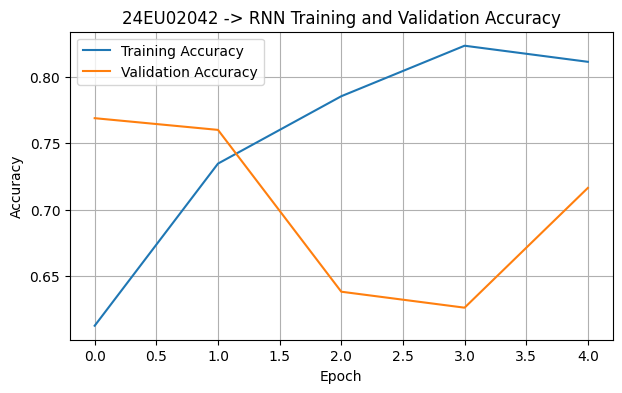

RNN performance graph generated successfully


In [ ]:
# Cell 13: RNN Training Performance
plt.figure(figsize=(7, 4))
plt.plot(rnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(rnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("24EU02042 -> RNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()
print("RNN performance graph generated successfully")


In [ ]:
# Cell 14: CNN vs RNN Comparison
print("----- Model Comparison -----")
print("CNN Test Accuracy:", round(cnn_accuracy * 100, 2), "%")
print("RNN Test Accuracy:", round(rnn_accuracy * 100, 2), "%")


----- Model Comparison -----
CNN Test Accuracy: 98.66 %
RNN Test Accuracy: 73.1 %


## Conclusion

CNN was implemented on MNIST for handwritten digit classification. RNN was implemented on IMDB for binary sentiment classification. Both models were trained, evaluated, and their training performance was visualized.